<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object    

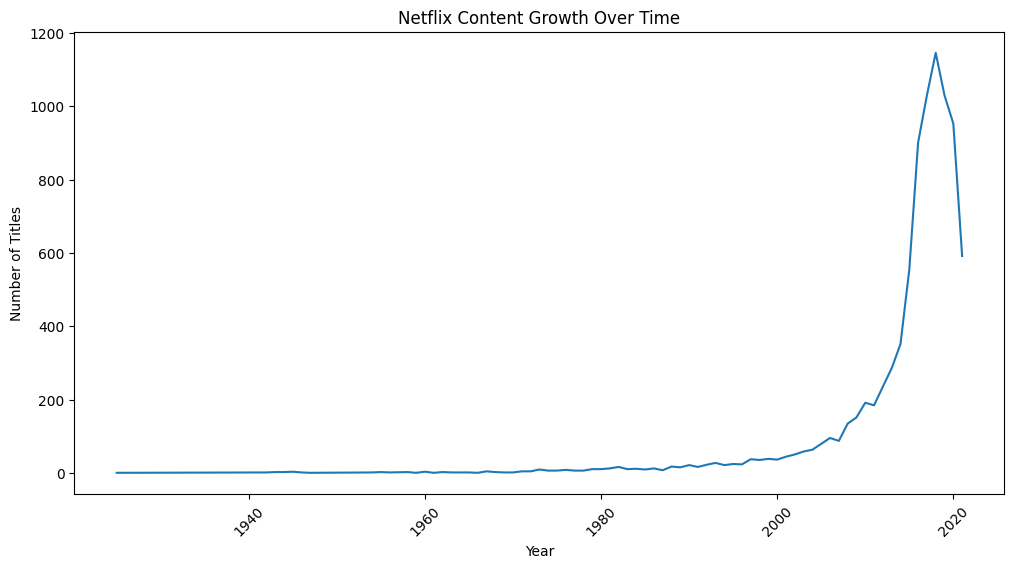

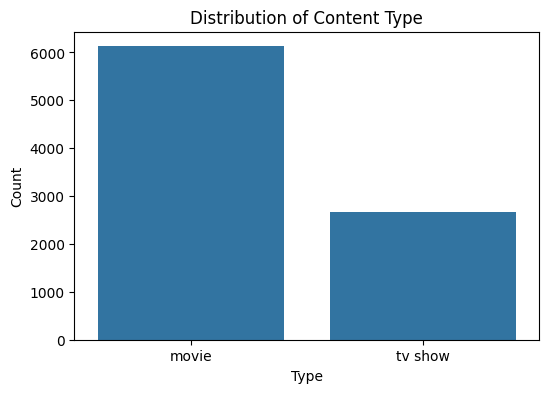

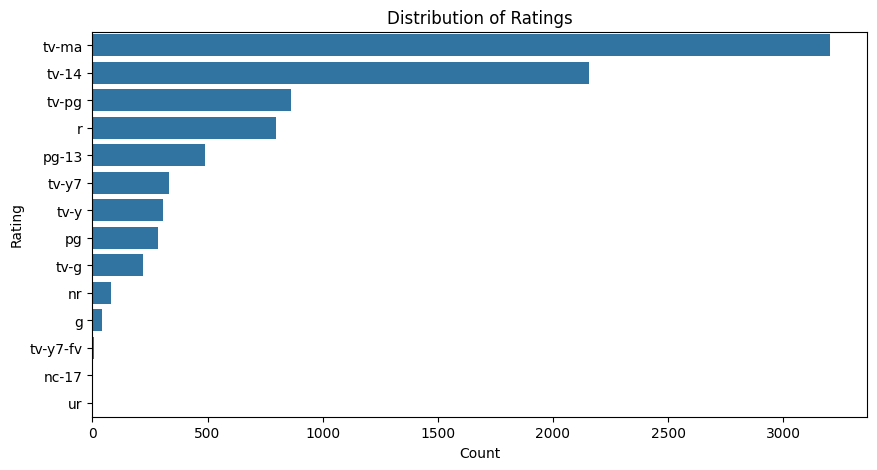

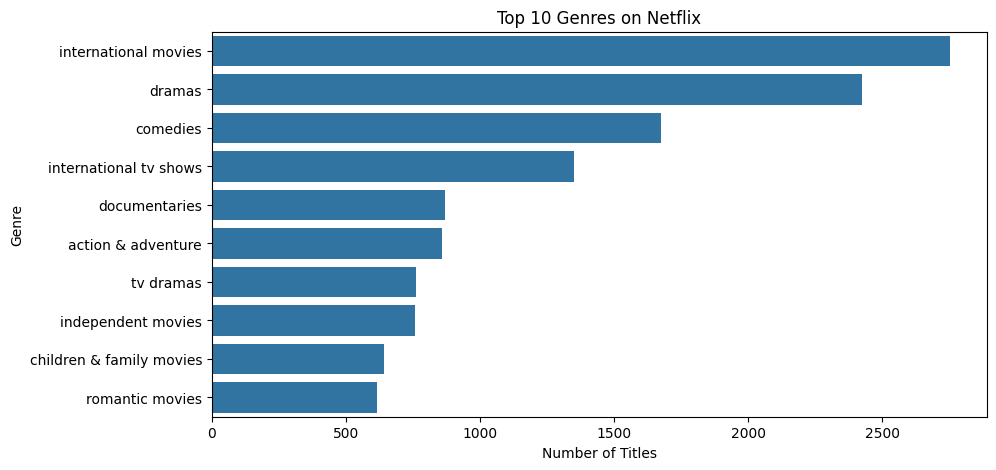

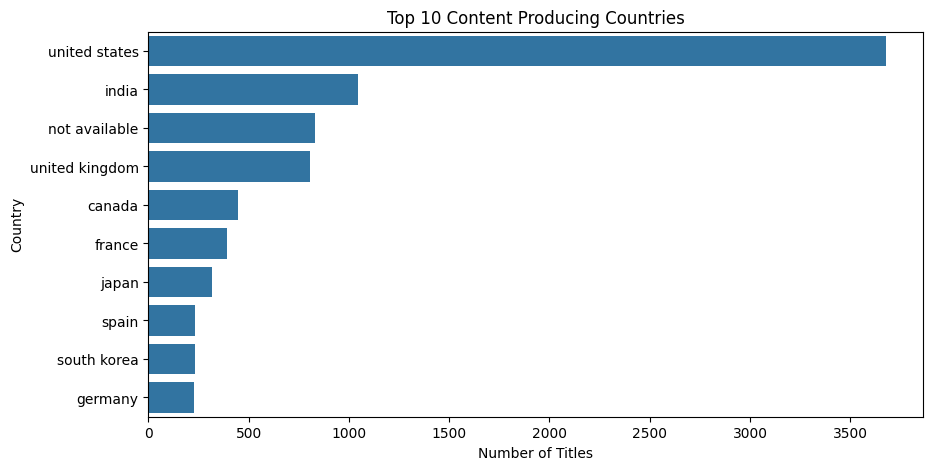

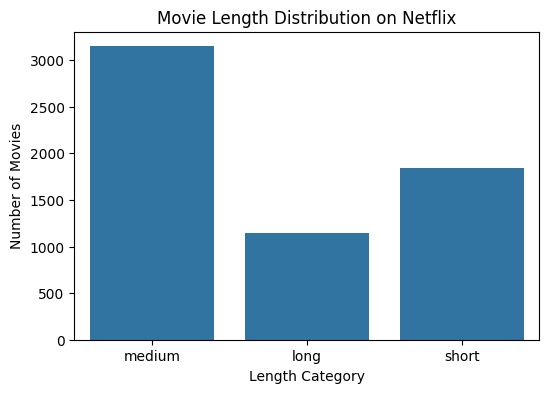

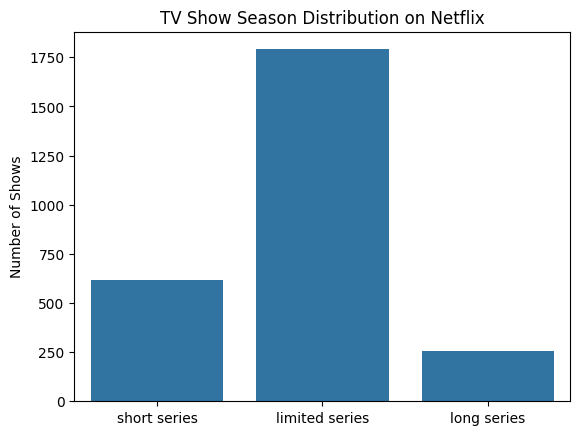

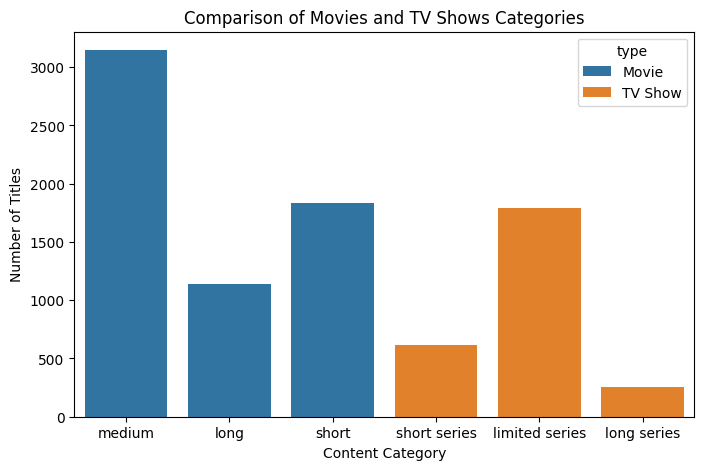

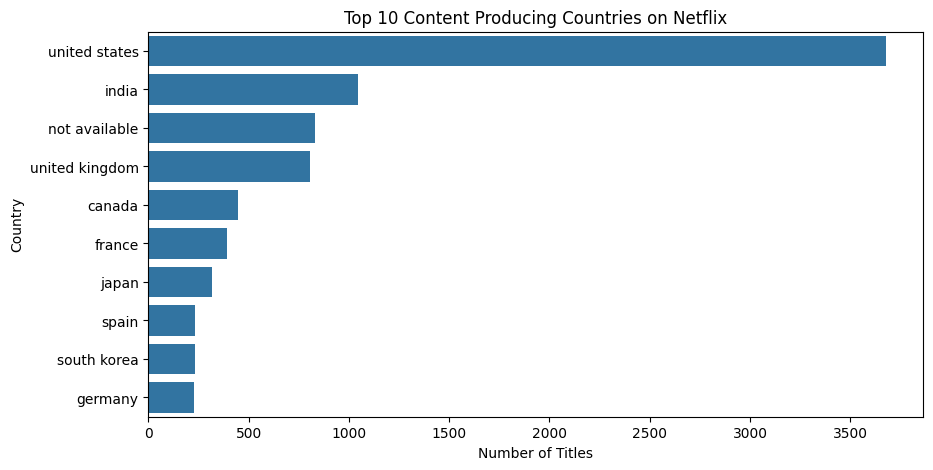

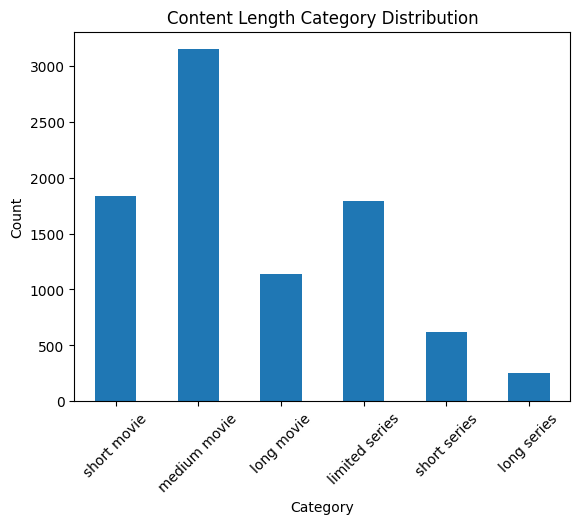

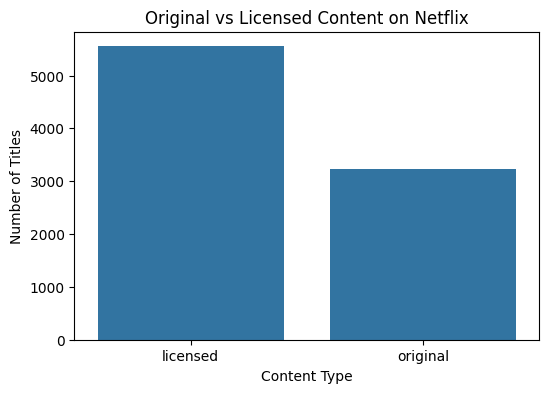

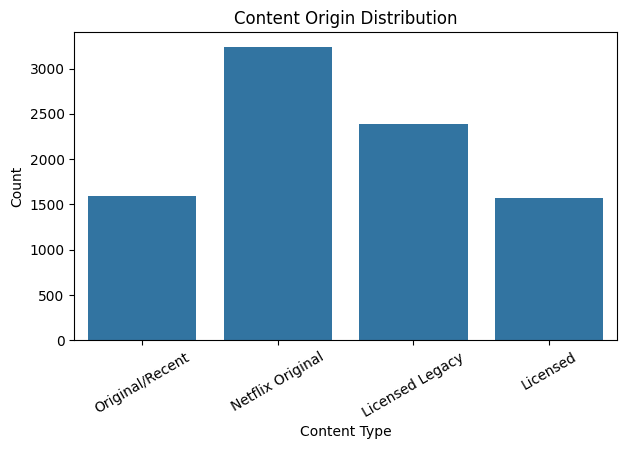

In [1]:
%run week_4.ipynb

### week-5 task

#### Use clustering to group Netflix titles by genre, duration, and ratings. 
#### Classification of content type (Movie vs. TV Show) based on features.

### 1.Use clustering to group Netflix titles by genre, duration, and ratings.

### Steps:

### 1. Data Selection: Select relevant features such as type, genre, duration, and rating.

### 2. Data Preprocessing: Convert duration into numeric format and create a feature to distinguish movies and TV shows.

### 3. Data Cleaning: Remove unnecessary columns and clean genre data.

### 4. Feature Engineering: Apply one-hot encoding to convert genres into multiple columns.

### 5. Encoding: Convert categorical variables like type and rating into numerical values.

### 6. Feature Scaling: Scale all features to bring them to the same range.

### 7. Optimal Cluster Selection: Use the Elbow Method to determine the best number of clusters.

### 8. Clustering: Apply K-Means algorithm to group similar data points.

### 9. Cluster Assignment: Assign each data point to a cluster.

### 10. Cluster Analysis: Analyze cluster characteristics using mean values.

### 11. Interpretation: Label clusters based on patterns (e.g., movies, TV shows, duration).

### 12. Insight Generation: Derive meaningful insights from the clustered data.

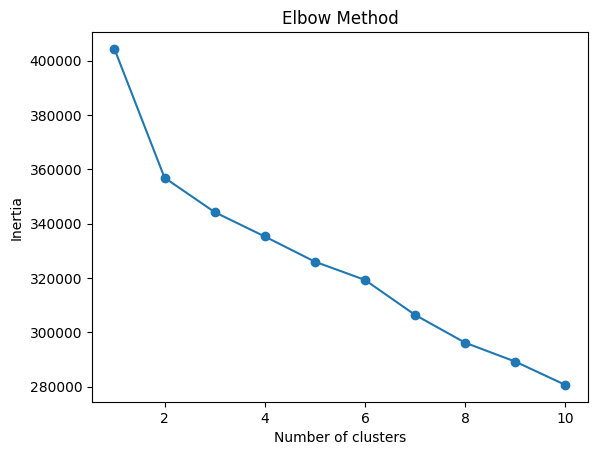

         type    rating  duration_num  is_tv_show  action&adventure  \
cluster                                                               
0         0.0  7.223388     77.402202         0.0          0.014158   
1         1.0  7.877252      1.751877         1.0          0.000000   
2         0.0  6.381133    109.611519         0.0          0.197203   

         animefeatures  animeseries  britishtvshows  children&familymovies  \
cluster                                                                      
0             0.008915     0.000000        0.000000               0.330362   
1             0.000000     0.065315        0.094595               0.000000   
2             0.012799     0.000000        0.000000               0.002607   

         classic&culttv  ...  teentvshows  thrillers  tvaction&adventure  \
cluster                  ...                                               
0               0.00000  ...     0.000000   0.000000            0.000000   
1               0.00976  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

# 1. Select required columns
df_new = df[['type', 'listed_in', 'duration', 'rating']].copy()

# 2. Extract numeric duration
df_new['duration_num'] = df_new['duration'].str.extract(r'(\d+)').astype(int)

# 3. Create TV show indicator
df_new['is_tv_show'] = df_new['duration'].str.contains('Season').astype(int)

# 4. Drop original duration
df_new = df_new.drop('duration', axis=1)

# 5. Clean genre column
df_new['listed_in'] = df_new['listed_in'].str.replace(' ', '')

# 6. One-hot encode genres
genre_dummies = df_new['listed_in'].str.get_dummies(sep=',')
df_new = pd.concat([df_new, genre_dummies], axis=1)
df_new = df_new.drop('listed_in', axis=1)

# 7. Encode categorical columns
le = LabelEncoder()
df_new['type'] = le.fit_transform(df_new['type'])
df_new['rating'] = le.fit_transform(df_new['rating'])

# 8. Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_new)

# 9. Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# 10. Apply KMeans (k = 3)
kmeans = KMeans(n_clusters=3, random_state=42)
df_new['cluster'] = kmeans.fit_predict(scaled_data)

# 11. Analyze clusters
print(df_new.groupby('cluster').mean())

# 12. Name clusters
df_new['cluster_name'] = df_new['cluster'].map({
    0: 'Medium Movies',
    1: 'TV Shows',
    2: 'Long Action Movies'
})

# 13. Cluster distribution
print(df_new['cluster_name'].value_counts())

#### Cluster Distribution

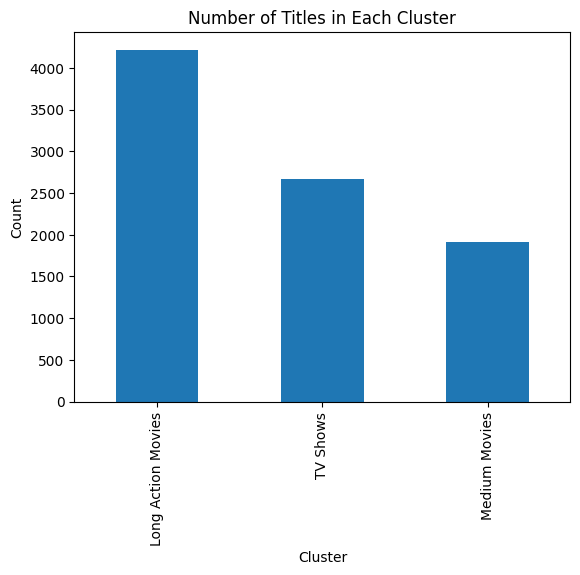

In [4]:
df_new['cluster_name'].value_counts().plot(kind='bar')
plt.title('Number of Titles in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

### Average Duration per Cluster

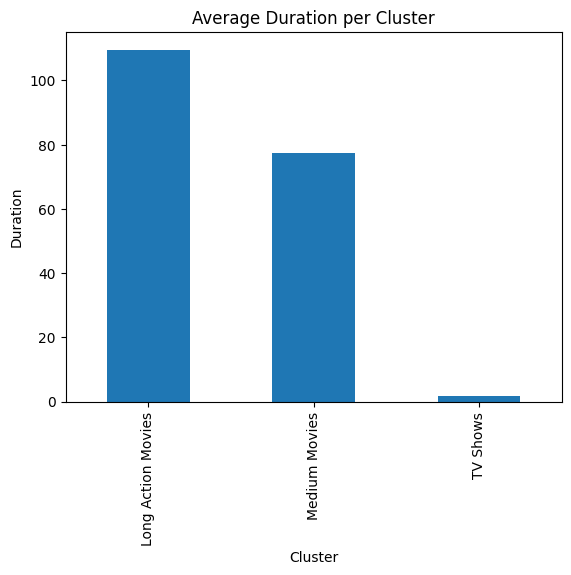

In [5]:
df_new.groupby('cluster_name')['duration_num'].mean().plot(kind='bar')
plt.title('Average Duration per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Duration')
plt.show()

### Average Rating per Cluster

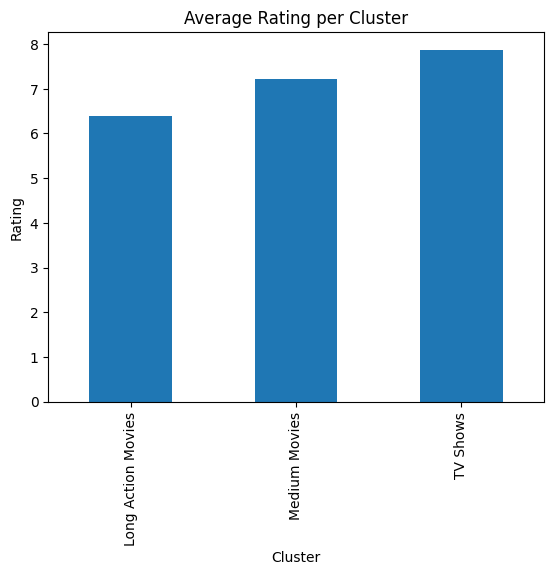

In [6]:
df_new.groupby('cluster_name')['rating'].mean().plot(kind='bar')
plt.title('Average Rating per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Rating')
plt.show()

### Top Genres in Each Cluster

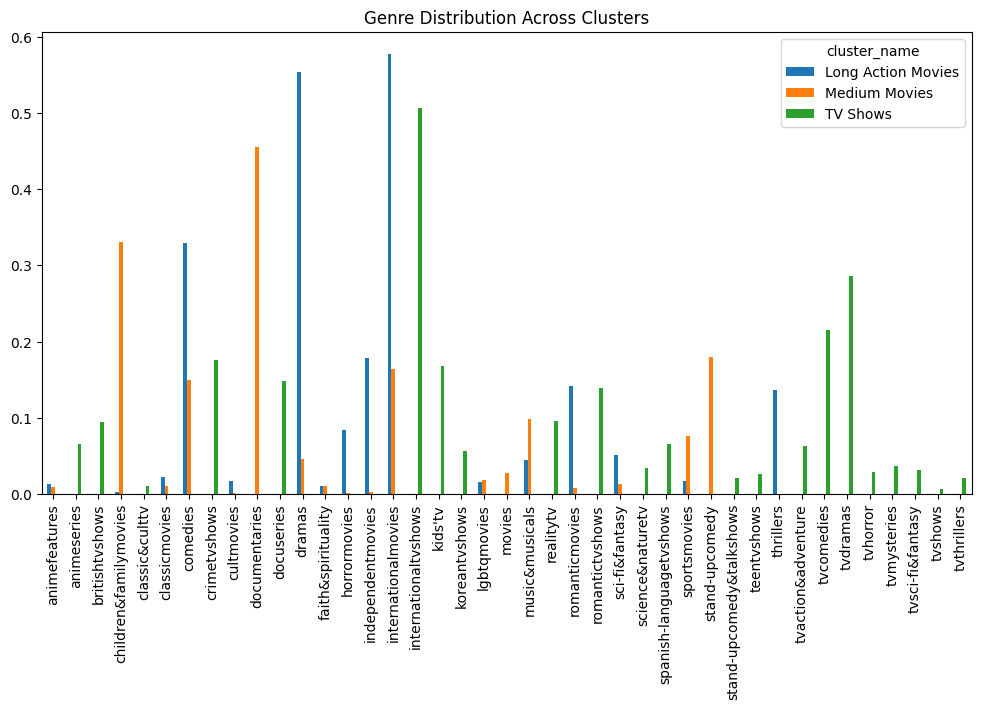

In [7]:
genre_cols = df_new.columns[5:-2]  # genre columns

df_new.groupby('cluster_name')[genre_cols].mean().T.plot(kind='bar', figsize=(12,6))
plt.title('Genre Distribution Across Clusters')
plt.show()

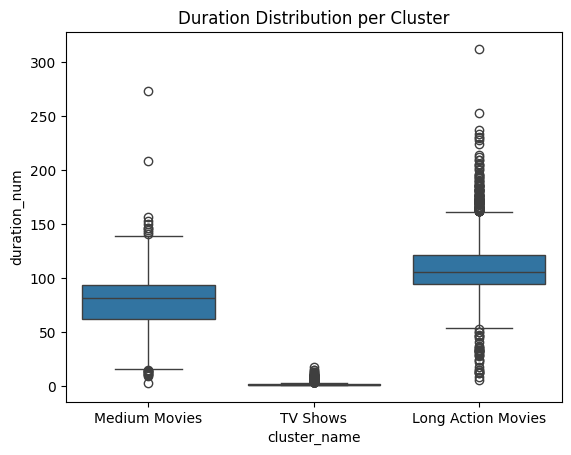

In [8]:
import seaborn as sns

sns.boxplot(x='cluster_name', y='duration_num', data=df_new)
plt.title('Duration Distribution per Cluster')
plt.show()

### 2.Classification of content type (Movie vs. TV Show) based on features. 

### Content Type Classification – Steps

### Previous Steps Completed:

### 1. Data Selection: Selected relevant features such as type, genre, duration, and rating.

### 2. Data Preprocessing: Extracted numeric values from duration and created a feature to distinguish Movies and TV Shows.

### 3. Data Cleaning: Removed unnecessary columns and cleaned genre data.

### 4. Feature Engineering: Converted genre into multiple columns using one-hot encoding.

### 5. Encoding: Converted categorical variables like type and rating into numerical values.

### 6. Feature Scaling: Scaled all features to bring them to the same range.

### 7. Clustering: Applied K-Means algorithm to group similar Netflix content.

---

### Classification Steps:

### 8. Feature Selection: Selected input features by removing target (type) and clustering columns.

### 9. Target Definition: Defined the target variable as content type (Movie or TV Show).

### 10. Data Splitting: Split the dataset into training and testing sets.

### 11. Model Training: Trained a Logistic Regression model using training data.

### 12. Prediction: Predicted content type on test data.

### 13. Model Evaluation: Evaluated model using accuracy, confusion matrix, and classification report.

### 14. Result Interpretation: Analyzed results to understand model performance.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target
X = df_new.drop(['type', 'cluster', 'cluster_name'], axis=1)
y = df_new['type']

# 2. Scale features (without target)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[1227    0]
 [   0  531]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       531

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



In [10]:
df_new['cluster_name'].value_counts()

cluster_name
Long Action Movies    4219
TV Shows              2664
Medium Movies         1907
Name: count, dtype: int64

In [11]:
df_new.groupby('cluster_name')['duration_num'].mean()

cluster_name
Long Action Movies    109.611519
Medium Movies          77.402202
TV Shows                1.751877
Name: duration_num, dtype: float64

In [12]:
df_new.groupby('cluster_name')['rating'].mean()

cluster_name
Long Action Movies    6.381133
Medium Movies         7.223388
TV Shows              7.877252
Name: rating, dtype: float64

### Confusion Matrix

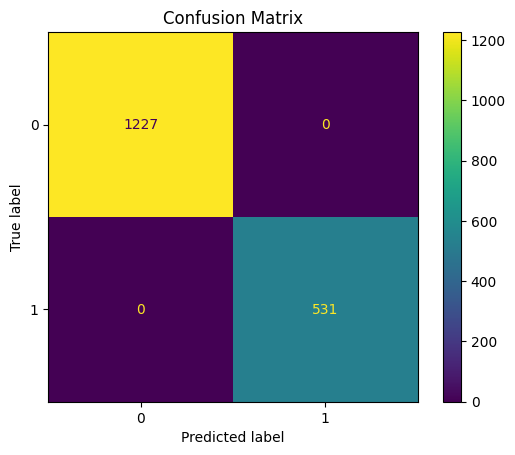

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

### Accuracy Score

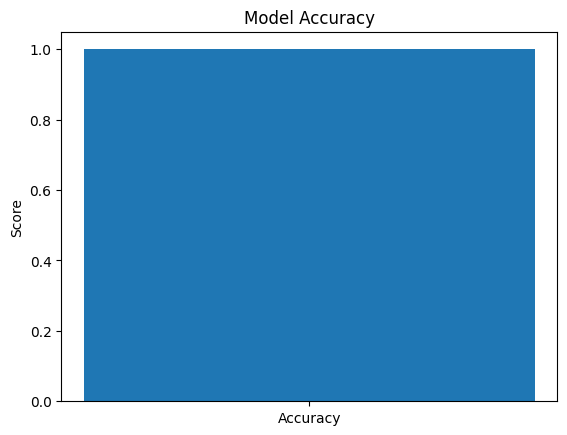

In [16]:
acc = accuracy_score(y_test, y_pred)

plt.bar(['Accuracy'], [acc])
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

### Precision, Recall, F1-score

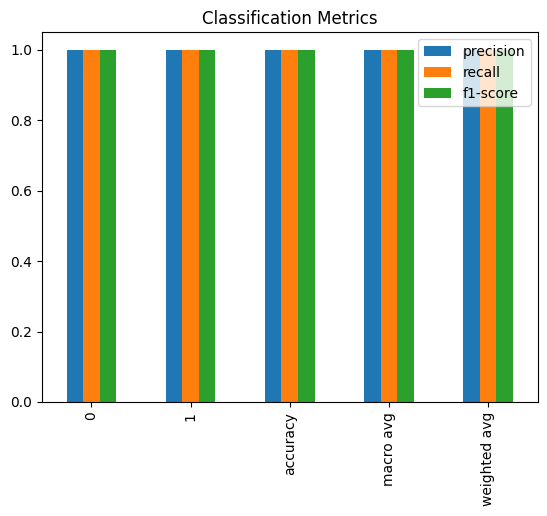

In [17]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df[['precision', 'recall', 'f1-score']].plot(kind='bar')
plt.title("Classification Metrics")
plt.show()

### Actual vs predicted

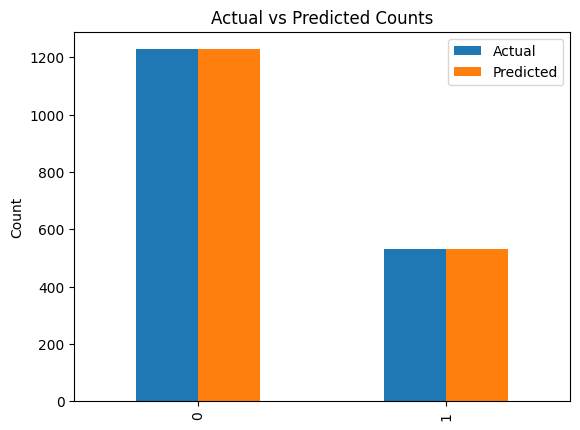

In [21]:
import pandas as pd

actual_counts = pd.Series(y_test).value_counts()
pred_counts = pd.Series(y_pred).value_counts()

df_compare = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': pred_counts
})

df_compare.plot(kind='bar')
plt.title("Actual vs Predicted Counts")
plt.ylabel("Count")
plt.show()